# PCA in a broader context.
#
## PCA is basically the application of eigen-decomposition to data analysis.
## You can do supervised clustering, denoising, and regression.
## The main question to address is whether you use the class column or not.
## PCA is normally applied without the class column, while
## LDA, FA, and PLS use the class column.

In [1]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn import datasets
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

In [2]:
# load some data

# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html
X, y = datasets.fetch_california_housing(return_X_y=True, as_frame=True)


In [3]:
print('Number of missing values:', X.isna().sum().sum())

Number of missing values: 0


In [4]:
model = Pipeline([
    ('scale', preprocessing.RobustScaler()),
    ('reg', LinearRegression())
])

# Show cross-validated R^2 scores
scores = cross_val_score(model, X, y, cv=10, n_jobs=-1)
print('R^2 scores for each fold:', scores)
print(f'Mean R^2: {scores.mean():.3f} (+/- {scores.std():.3f})')

R^2 scores for each fold: [0.48254494 0.61416063 0.42274892 0.48178521 0.55705986 0.5412919
 0.47496038 0.45844938 0.48177943 0.59528796]
Mean R^2: 0.511 (+/- 0.059)


In [5]:
# we need to see the number of eigenvalues larger or equal 1.0

pcr = Pipeline([
    ('std', preprocessing.StandardScaler()),
    ('pca', PCA())
])

pcr.fit(X, y)
pca_step = pcr.named_steps['pca']

In [6]:
ev = pca_step.explained_variance_        # eigenvalues
print("Eigenvalues:", ev)

explained_variance = pca_step.explained_variance_ratio_.cumsum()
print("Percentage of explained variance:", np.around(explained_variance*100, 2))

Eigenvalues: [2.02704763 1.88139074 1.27115235 1.03108764 1.0031042  0.65941198
 0.08160574 0.04558733]
Percentage of explained variance: [ 25.34  48.85  64.74  77.63  90.17  98.41  99.43 100.  ]


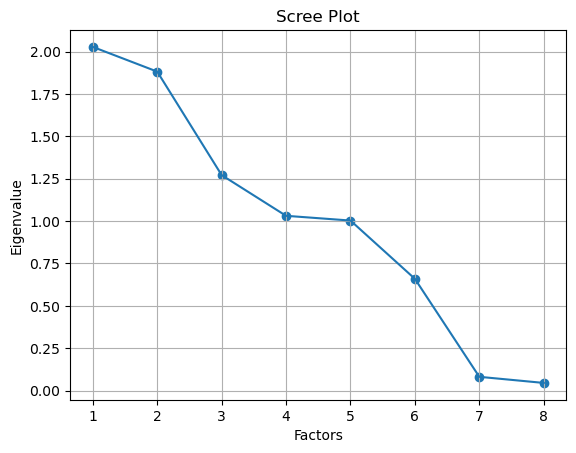

In [7]:
# Create scree plot using matplotlib
plt.scatter(range(1, len(ev)+1), ev)
plt.plot(range(1, len(ev)+1), ev)
plt.title('Scree Plot')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

In [8]:
# Option 1. let's now re-run our PCR with the n best components

pcr = Pipeline([
    ('std', preprocessing.StandardScaler()),
    ('pca', PCA(n_components = 5)),
    ('lin', LinearRegression())
])

# Show cross-validated R^2 scores
scores = cross_val_score(pcr, X, y, cv=10, n_jobs=-1)
print('R^2 scores for each fold:', scores)
print(f'Mean R^2: {scores.mean():.3f} (+/- {scores.std():.3f})')

R^2 scores for each fold: [ 0.45779145  0.27897653  0.23764414  0.50824369  0.38947039  0.51681472
 -0.05718525  0.12827464  0.1462392   0.33592515]
Mean R^2: 0.294 (+/- 0.176)


In [9]:
# Let's re-check the eigenvalues and explained variance ...
pcr.fit(X, y)
pca_step = pcr.named_steps['pca']
ev = pca_step.explained_variance_        # eigenvalues
explained_variance = pca_step.explained_variance_ratio_.sum()
print("PCR with ", len(ev), "Principal Components and explained variance of", round(explained_variance*100,2), "%")

PCR with  5 Principal Components and explained variance of 90.17 %


In [10]:
# Option 2. let's now re-run our PCR with 95% of explained variance
pcr.set_params(pca__n_components=0.95, pca__svd_solver='full')

,steps,"[('std', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,0.95
,copy,True
,whiten,False
,svd_solver,'full'


In [11]:
# Let's re-check the eigenvalues and explained variance ...
pcr.fit(X, y)
pca_step = pcr.named_steps['pca']
ev = pca_step.explained_variance_        # eigenvalues
explained_variance = pca_step.explained_variance_ratio_.sum()
print("PCR with ", len(ev), "Principal Components and explained variance of", round(explained_variance*100,2), "%")

PCR with  6 Principal Components and explained variance of 98.41 %


In [12]:
# Show cross-validated R^2 scores
scores = cross_val_score(pcr, X, y, cv=10, n_jobs=-1)
print('R^2 scores for each fold:', scores)
print(f'Mean R^2: {scores.mean():.3f} (+/- {scores.std():.3f})')

R^2 scores for each fold: [0.55160119 0.40136124 0.29304504 0.49635753 0.45365723 0.49987325
 0.04372206 0.30681374 0.20521283 0.41566283]
Mean R^2: 0.367 (+/- 0.148)


In [ ]:
# A related technique is Partial Least Square Regression.
# Similar to PCA, it transform the feature space into another
# dimension (principal components), but it uses the outcome variable.
# https://scikit-learn.org/stable/auto_examples/cross_decomposition/plot_compare_cross_decomposition.html

pls = Pipeline([
    ('pls', PLSRegression(n_components=5, scale=True))
])

# Show cross-validated R^2 scores
scores = cross_val_score(pls, X, y, cv=10, n_jobs=-1)
print('R^2 scores for each fold:', scores)
print(f'Mean R^2: {scores.mean():.3f} (+/- {scores.std():.3f})')

R^2 scores for each fold: [0.47209667 0.61334674 0.43187424 0.4763264  0.55314357 0.53359916
 0.46501191 0.46087425 0.47196361 0.5742576 ]
Mean R^2: 0.505 (+/- 0.056)


In [14]:
# Let's try something else ...
from sklearn import ensemble

rfr = Pipeline([
    ('scale', preprocessing.PowerTransformer()),
    ('rf', ensemble.GradientBoostingRegressor())        # RF & GBM = 0.63
])

# Show cross-validated R^2 scores
scores = cross_val_score(rfr, X, y, cv=10, n_jobs=-1)
print('R^2 scores for each fold:', scores)
print(f'Mean R^2: {scores.mean():.3f} (+/- {scores.std():.3f})')

R^2 scores for each fold: [0.30673178 0.72930397 0.70229918 0.68280128 0.7673823  0.64752857
 0.62422458 0.61599353 0.50535734 0.69353167]
Mean R^2: 0.628 (+/- 0.127)


In [19]:
from sklearn.preprocessing import RobustScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipe_rf = Pipeline([
  ('std', RobustScaler()),
  ('rf', RandomForestRegressor())
])

print("Score: %.3f" % pipe_rf.fit(X_train, y_train).score(X_test, y_test))
y_pred = pipe_rf.predict(X_test)
rf_r2 = pipe_rf.score(X_test, y_test)
rf_rmse = root_mean_squared_error(y_test, pipe_rf.predict(X_test))
print("RMSE: %.3f" % root_mean_squared_error(y_test, y_pred))

Score: 0.806
RMSE: 0.505


In [17]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error

pipe_gb = Pipeline([
  ('std', RobustScaler()),
  ('gb', GradientBoostingRegressor(random_state=42))
])

print("Score: %.3f" % pipe_gb.fit(X_train, y_train).score(X_test, y_test))
y_pred_gb = pipe_gb.predict(X_test)
gb_rmse = root_mean_squared_error(y_test, y_pred_gb)
gb_r2 = pipe_gb.score(X_test, y_test)
print("RMSE: %.3f" % gb_rmse)

Score: 0.776
RMSE: 0.542


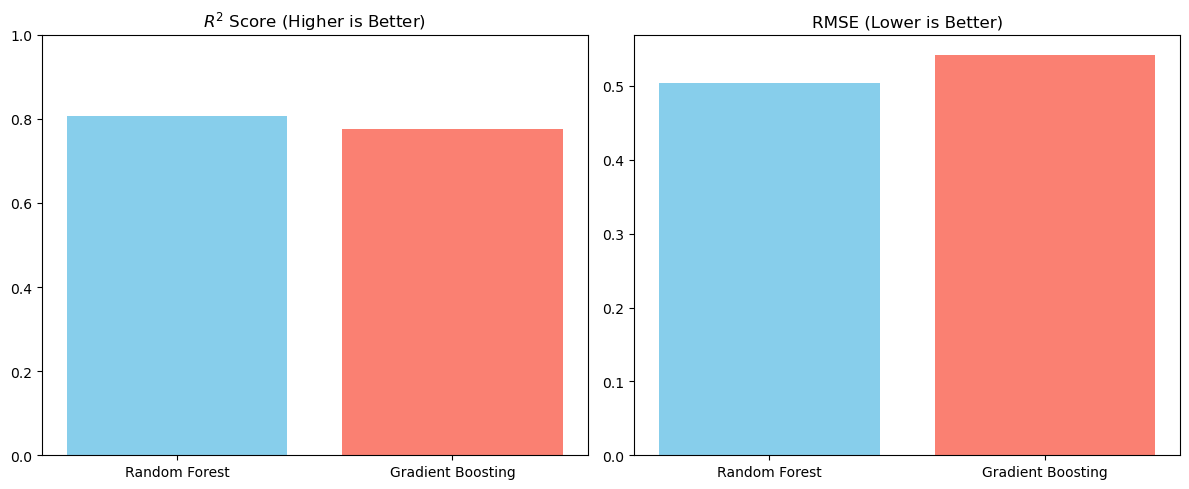

In [20]:
model_names = ['Random Forest', 'Gradient Boosting']
r2_values = [rf_r2, gb_r2]
rmse_values = [rf_rmse, gb_rmse]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1: R-Squared
ax1.bar(model_names, r2_values, color=['skyblue', 'salmon'])
ax1.set_title('$R^2$ Score (Higher is Better)')
ax1.set_ylim(0, 1) # Set scale from 0 to 1

# Chart 2: RMSE
ax2.bar(model_names, rmse_values, color=['skyblue', 'salmon'])
ax2.set_title('RMSE (Lower is Better)')

plt.tight_layout()
plt.show()

In [21]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd

# 1. Load the dataset
california = fetch_california_housing()
X, y = california.data, california.target

# 2. Define models
# Using Pipelines to ensure proper scaling for linear models
models = {
    'Linear Regression': Pipeline([('scaler', StandardScaler()), ('reg', LinearRegression())]),
    'Ridge (L2)': Pipeline([('scaler', StandardScaler()), ('reg', Ridge(alpha=1.0))]),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

# 3. Perform 5-Fold Cross-Validation
results = []
scoring = {'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'}

for name, model in models.items():
    cv_results = cross_validate(model, X, y, cv=5, scoring=scoring, n_jobs=-1)
    results.append({
        'Model': name,
        'Mean R²': cv_results['test_r2'].mean(),
        'Mean RMSE': -cv_results['test_rmse'].mean()
    })

# 4. Present the Comparative Analysis Table
df_comparison = pd.DataFrame(results).sort_values(by='Mean R²', ascending=False)
print(df_comparison.to_string(index=False))

            Model  Mean R²  Mean RMSE
Gradient Boosting 0.669829   0.641598
    Random Forest 0.656119   0.650522
       Ridge (L2) 0.553034   0.745904
Linear Regression 0.553031   0.745907


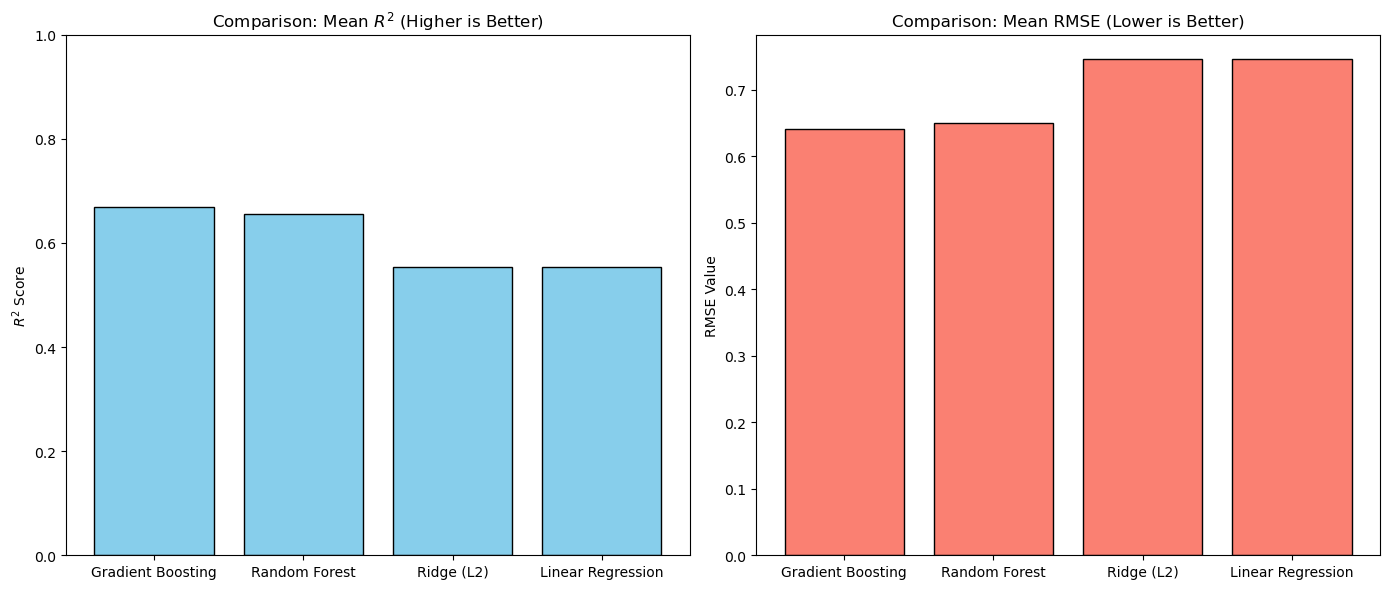

            Model  Mean R2  Mean RMSE
Gradient Boosting 0.669829   0.641598
    Random Forest 0.656119   0.650522
       Ridge (L2) 0.553034   0.745904
Linear Regression 0.553031   0.745907


In [22]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Load data
california = fetch_california_housing()
X, y = california.data, california.target

# 2. Define models
models = {
    'Linear Regression': Pipeline([('scaler', StandardScaler()), ('reg', LinearRegression())]),
    'Ridge (L2)': Pipeline([('scaler', StandardScaler()), ('reg', Ridge())]),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

# 3. Cross-validation
results = []
scoring = {'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'}

for name, model in models.items():
    cv_results = cross_validate(model, X, y, cv=5, scoring=scoring, n_jobs=-1)
    results.append({
        'Model': name,
        'Mean R2': cv_results['test_r2'].mean(),
        'Mean RMSE': -cv_results['test_rmse'].mean()
    })

df_res = pd.DataFrame(results)

# 4. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Sort R2 (Higher is better)
df_r2 = df_res.sort_values('Mean R2', ascending=False)
ax1.bar(df_r2['Model'], df_r2['Mean R2'], color='skyblue', edgecolor='black')
ax1.set_title('Comparison: Mean $R^2$ (Higher is Better)')
ax1.set_ylabel('$R^2$ Score')
ax1.set_ylim(0, 1)

# Sort RMSE (Lower is better)
df_rmse = df_res.sort_values('Mean RMSE', ascending=True)
ax2.bar(df_rmse['Model'], df_rmse['Mean RMSE'], color='salmon', edgecolor='black')
ax2.set_title('Comparison: Mean RMSE (Lower is Better)')
ax2.set_ylabel('RMSE Value')

plt.tight_layout()
plt.show()

# Display the table
print(df_res.sort_values('Mean R2', ascending=False).to_string(index=False))